# Assignment 1 - SMS Spam Classification
Jugaad Singh Sohal (MDS202421)
## Model Training

In this notebook we will train different models on the SMS spam data and compare their performance.

### Setup

In [1]:
%pip install pandas numpy scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_recall_curve, roc_curve, auc
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

### Load the data splits

In [3]:
train_df = pd.read_csv('data/train.csv')
val_df = pd.read_csv('data/validation.csv')
test_df = pd.read_csv('data/test.csv')

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
train_df.head()

Train: 3900, Val: 836, Test: 836


,label,message
0,spam,"Goal! Arsenal 4 (Henry, 7 v Liverpool 2 Henry ..."
1,ham,"They said if its gonna snow, it will start aro..."
2,ham,Aah bless! How's your arm?
3,ham,Oh k. . I will come tomorrow
4,ham,What's happening with you. Have you gotten a j...


In [4]:
# separate features and labels
X_train = train_df['message']
y_train = (train_df['label'] == 'spam').astype(int)

X_val = val_df['message']
y_val = (val_df['label'] == 'spam').astype(int)

X_test = test_df['message']
y_test = (test_df['label'] == 'spam').astype(int)

print(f"Training samples: {len(X_train)}, Spam: {y_train.sum()}")

Training samples: 3900, Spam: 523


### Feature Extraction - TF-IDF

Converting text to numerical features using TF-IDF (Term Frequency - Inverse Document Frequency)

In [ ]:
# create tfidf vectorizer
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print(f"TF-IDF features: {X_train_tfidf.shape[1]}")
print(f"Train shape: {X_train_tfidf.shape}")

TF-IDF features: 5000
Train shape: (3900, 5000)


### Model 1: Rule-based Baseline

Simple keyword matching - if message contains spam keywords, classify as spam.

In [ ]:
# spam keywords based on EDA findings
spam_keywords = ['free', 'win', 'winner', 'cash', 'prize', 'claim', 'urgent', 
                 'call', 'txt', 'text', 'mobile', 'reply', 'stop', 'www', 
                 'click', 'subscribe', 'ringtone', 'nokia', 'award', 'congratulations']

def rule_based_predict(messages):
    predictions = []
    for msg in messages:
        msg_lower = msg.lower()
        # count how many spam keywords are in the message
        keyword_count = sum(1 for kw in spam_keywords if kw in msg_lower)
        # if 2 or more keywords, classify as spam (rule)
        if keyword_count >= 2:
            predictions.append(1)
        else:
            predictions.append(0)
    return np.array(predictions)

In [7]:
# evaluate rule-based model on train and validation
y_train_pred_rule = rule_based_predict(X_train)
y_val_pred_rule = rule_based_predict(X_val)

print("Rule-based Model Results:")
print("\nTraining Set:")
print(f"  Accuracy: {accuracy_score(y_train, y_train_pred_rule):.4f}")
print(f"  Precision: {precision_score(y_train, y_train_pred_rule):.4f}")
print(f"  Recall: {recall_score(y_train, y_train_pred_rule):.4f}")
print(f"  F1: {f1_score(y_train, y_train_pred_rule):.4f}")

print("\nValidation Set:")
print(f"  Accuracy: {accuracy_score(y_val, y_val_pred_rule):.4f}")
print(f"  Precision: {precision_score(y_val, y_val_pred_rule):.4f}")
print(f"  Recall: {recall_score(y_val, y_val_pred_rule):.4f}")
print(f"  F1: {f1_score(y_val, y_val_pred_rule):.4f}")

Rule-based Model Results:

Training Set:
  Accuracy: 0.9538
  Precision: 0.8998
  Recall: 0.7380
  F1: 0.8109

Validation Set:
  Accuracy: 0.9581
  Precision: 0.9753
  Recall: 0.7054
  F1: 0.8187


In [8]:
# confusion matrix for rule-based
print("Confusion Matrix (Validation):")
print(confusion_matrix(y_val, y_val_pred_rule))
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_rule, target_names=['ham', 'spam']))

Confusion Matrix (Validation):
[[722   2]
 [ 33  79]]

Classification Report:
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       724
        spam       0.98      0.71      0.82       112

    accuracy                           0.96       836
   macro avg       0.97      0.85      0.90       836
weighted avg       0.96      0.96      0.96       836

[[722   2]
 [ 33  79]]

Classification Report:
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       724
        spam       0.98      0.71      0.82       112

    accuracy                           0.96       836
   macro avg       0.97      0.85      0.90       836
weighted avg       0.96      0.96      0.96       836



### Model 2: TF-IDF + Logistic Regression

In [9]:
# train logistic regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)

# predictions
y_train_pred_lr = lr_model.predict(X_train_tfidf)
y_val_pred_lr = lr_model.predict(X_val_tfidf)

# probabilities
y_train_prob_lr = lr_model.predict_proba(X_train_tfidf)[:, 1]
y_val_prob_lr = lr_model.predict_proba(X_val_tfidf)[:, 1]

print("Logistic Regression Results:")
print("\nTraining Set:")
print(f"  Accuracy: {accuracy_score(y_train, y_train_pred_lr):.4f}")
print(f"  Precision: {precision_score(y_train, y_train_pred_lr):.4f}")
print(f"  Recall: {recall_score(y_train, y_train_pred_lr):.4f}")
print(f"  F1: {f1_score(y_train, y_train_pred_lr):.4f}")

print("\nValidation Set:")
print(f"  Accuracy: {accuracy_score(y_val, y_val_pred_lr):.4f}")
print(f"  Precision: {precision_score(y_val, y_val_pred_lr):.4f}")
print(f"  Recall: {recall_score(y_val, y_val_pred_lr):.4f}")
print(f"  F1: {f1_score(y_val, y_val_pred_lr):.4f}")

Logistic Regression Results:

Training Set:
  Accuracy: 0.9710
  Precision: 0.9928
  Recall: 0.7897
  F1: 0.8797

Validation Set:
  Accuracy: 0.9629
  Precision: 1.0000
  Recall: 0.7232
  F1: 0.8394


In [10]:
# confusion matrix
print("Confusion Matrix (Validation):")
print(confusion_matrix(y_val, y_val_pred_lr))
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_lr, target_names=['ham', 'spam']))

Confusion Matrix (Validation):
[[724   0]
 [ 31  81]]

Classification Report:
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       724
        spam       1.00      0.72      0.84       112

    accuracy                           0.96       836
   macro avg       0.98      0.86      0.91       836
weighted avg       0.96      0.96      0.96       836



### Model 3: TF-IDF + Naive Bayes

In [11]:
# train naive bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

# predictions
y_train_pred_nb = nb_model.predict(X_train_tfidf)
y_val_pred_nb = nb_model.predict(X_val_tfidf)

# probabilities
y_train_prob_nb = nb_model.predict_proba(X_train_tfidf)[:, 1]
y_val_prob_nb = nb_model.predict_proba(X_val_tfidf)[:, 1]

print("Naive Bayes Results:")
print("\nTraining Set:")
print(f"  Accuracy: {accuracy_score(y_train, y_train_pred_nb):.4f}")
print(f"  Precision: {precision_score(y_train, y_train_pred_nb):.4f}")
print(f"  Recall: {recall_score(y_train, y_train_pred_nb):.4f}")
print(f"  F1: {f1_score(y_train, y_train_pred_nb):.4f}")

print("\nValidation Set:")
print(f"  Accuracy: {accuracy_score(y_val, y_val_pred_nb):.4f}")
print(f"  Precision: {precision_score(y_val, y_val_pred_nb):.4f}")
print(f"  Recall: {recall_score(y_val, y_val_pred_nb):.4f}")
print(f"  F1: {f1_score(y_val, y_val_pred_nb):.4f}")

Naive Bayes Results:

Training Set:
  Accuracy: 0.9854
  Precision: 1.0000
  Recall: 0.8910
  F1: 0.9424

Validation Set:
  Accuracy: 0.9701
  Precision: 1.0000
  Recall: 0.7768
  F1: 0.8744


In [12]:
# confusion matrix
print("Confusion Matrix (Validation):")
print(confusion_matrix(y_val, y_val_pred_nb))
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_nb, target_names=['ham', 'spam']))

Confusion Matrix (Validation):
[[724   0]
 [ 25  87]]

Classification Report:
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       724
        spam       1.00      0.78      0.87       112

    accuracy                           0.97       836
   macro avg       0.98      0.89      0.93       836
weighted avg       0.97      0.97      0.97       836



### Model 4: TF-IDF + SVM (Support Vector Machine)

In [13]:
# train SVM
svm_model = LinearSVC(random_state=42, max_iter=2000)
svm_model.fit(X_train_tfidf, y_train)

# predictions
y_train_pred_svm = svm_model.predict(X_train_tfidf)
y_val_pred_svm = svm_model.predict(X_val_tfidf)

# SVM decision scores
y_train_score_svm = svm_model.decision_function(X_train_tfidf)
y_val_score_svm = svm_model.decision_function(X_val_tfidf)

print("SVM Results:")
print("\nTraining Set:")
print(f"  Accuracy: {accuracy_score(y_train, y_train_pred_svm):.4f}")
print(f"  Precision: {precision_score(y_train, y_train_pred_svm):.4f}")
print(f"  Recall: {recall_score(y_train, y_train_pred_svm):.4f}")
print(f"  F1: {f1_score(y_train, y_train_pred_svm):.4f}")

print("\nValidation Set:")
print(f"  Accuracy: {accuracy_score(y_val, y_val_pred_svm):.4f}")
print(f"  Precision: {precision_score(y_val, y_val_pred_svm):.4f}")
print(f"  Recall: {recall_score(y_val, y_val_pred_svm):.4f}")
print(f"  F1: {f1_score(y_val, y_val_pred_svm):.4f}")

SVM Results:

Training Set:
  Accuracy: 0.9997
  Precision: 1.0000
  Recall: 0.9981
  F1: 0.9990

Validation Set:
  Accuracy: 0.9833
  Precision: 0.9804
  Recall: 0.8929
  F1: 0.9346


In [14]:
# confusion matrix
print("Confusion Matrix (Validation):")
print(confusion_matrix(y_val, y_val_pred_svm))
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_svm, target_names=['ham', 'spam']))

Confusion Matrix (Validation):
[[722   2]
 [ 12 100]]

Classification Report:
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       724
        spam       0.98      0.89      0.93       112

    accuracy                           0.98       836
   macro avg       0.98      0.95      0.96       836
weighted avg       0.98      0.98      0.98       836



### Model Comparison Summary (Validation Set)

| Model | Accuracy | Precision | Recall | F1 | FP | FN |
|-------|----------|-----------|--------|-----|----|----|
| Rule-based | 95.81% | 97.53% | 70.54% | 0.82 | 2 | 33 |
| Logistic Regression | 96.29% | 100% | 72.32% | 0.84 | 0 | 31 |
| Naive Bayes | 97.01% | 100% | 77.68% | 0.87 | 0 | 25 |
| SVM | 98.33% | 98.04% | 89.29% | 0.93 | 2 | 12 |

**Key Observations:**
- SVM has best F1 and recall but has 2 false positives
- Naive Bayes and Logistic Regression have perfect precision (0 FPs)
- Using class example FP is 10x more costly than FN (removing genuine message is worse than missing spam), Naive Bayes might be preferred despite lower F1

### Hyperparameter Tuning

Fine-tuning the models using GridSearchCV on training data with cross-validation.

In [19]:
# Hyperparameter tuning for Logistic Regression
lr_params = {
    'C': [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 50, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'class_weight': [None, 'balanced']
}

lr_grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), 
                       lr_params, cv=5, scoring='f1', n_jobs=-1)
lr_grid.fit(X_train_tfidf, y_train)

print("Logistic Regression - Best params:", lr_grid.best_params_)
print(f"Best CV F1: {lr_grid.best_score_:.4f}")

Logistic Regression - Best params: {'C': 50, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
Best CV F1: 0.9402


In [20]:
# Hyperparameter tuning for Naive Bayes
nb_params = {
    'alpha': [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0],
    'fit_prior': [True, False]
}

nb_grid = GridSearchCV(MultinomialNB(), nb_params, cv=5, scoring='f1', n_jobs=-1)
nb_grid.fit(X_train_tfidf, y_train)

print("Naive Bayes - Best params:", nb_grid.best_params_)
print(f"Best CV F1: {nb_grid.best_score_:.4f}")

Naive Bayes - Best params: {'alpha': 0.1, 'fit_prior': True}
Best CV F1: 0.9359


In [21]:
# Hyperparameter tuning for SVM
svm_params = {
    'C': [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 50, 100],
    'loss': ['hinge', 'squared_hinge'],
    'class_weight': [None, 'balanced']
}

svm_grid = GridSearchCV(LinearSVC(random_state=42, max_iter=5000), 
                        svm_params, cv=5, scoring='f1', n_jobs=-1)
svm_grid.fit(X_train_tfidf, y_train)

print("SVM - Best params:", svm_grid.best_params_)
print(f"Best CV F1: {svm_grid.best_score_:.4f}")

SVM - Best params: {'C': 1, 'class_weight': 'balanced', 'loss': 'squared_hinge'}
Best CV F1: 0.9406


In [26]:
# Summary of tuned models
print("Hyperparameter Tuning Summary:")
print(f"\nLogistic Regression: {lr_grid.best_params_}")
print(f"  Best CV F1: {lr_grid.best_score_:.4f}")
print(f"\nNaive Bayes: {nb_grid.best_params_}")
print(f"  Best CV F1: {nb_grid.best_score_:.4f}")
print(f"\nSVM: {svm_grid.best_params_}")
print(f"  Best CV F1: {svm_grid.best_score_:.4f}")

Hyperparameter Tuning Summary:

Logistic Regression: {'C': 50, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
  Best CV F1: 0.9402

Naive Bayes: {'alpha': 0.1, 'fit_prior': True}
  Best CV F1: 0.9359

SVM: {'C': 1, 'class_weight': 'balanced', 'loss': 'squared_hinge'}
  Best CV F1: 0.9406


### Benchmark: Score Tuned Models on Test Data

Evaluating all three tuned benchmark models on the held-out test set to select the best one.

In [28]:
# Get best estimators from GridSearchCV
lr_tuned = lr_grid.best_estimator_
nb_tuned = nb_grid.best_estimator_
svm_tuned = svm_grid.best_estimator_

# Score on test data
y_test_pred_lr = lr_tuned.predict(X_test_tfidf)
y_test_pred_nb = nb_tuned.predict(X_test_tfidf)
y_test_pred_svm = svm_tuned.predict(X_test_tfidf)

# Collect metrics for all models
models = ['Logistic Regression', 'Naive Bayes', 'SVM']
predictions = [y_test_pred_lr, y_test_pred_nb, y_test_pred_svm]

results = []
for name, y_pred in zip(models, predictions):
    cm = confusion_matrix(y_test, y_pred)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'FP': cm[0, 1],
        'FN': cm[1, 0]
    })

results_df = pd.DataFrame(results)

print("On Test Set Results:")
results_df

On Test Set Results:


,Model,Accuracy,Precision,Recall,F1,FP,FN
0,Logistic Regression,0.982057,0.944954,0.919643,0.932127,6,9
1,Naive Bayes,0.983254,0.962264,0.910714,0.935780,4,10
2,SVM,0.982057,0.944954,0.919643,0.932127,6,9


In [29]:
# Select best model based on F1 score
best_idx = results_df['F1'].idxmax()
best_model_name = results_df.loc[best_idx, 'Model']
best_f1 = results_df.loc[best_idx, 'F1']

print(f"\nBest Model: {best_model_name}")
print(f"Test F1 Score: {best_f1:.4f}")
print(f"Test Precision: {results_df.loc[best_idx, 'Precision']:.4f}")
print(f"Test Recall: {results_df.loc[best_idx, 'Recall']:.4f}")
print(f"False Positives: {results_df.loc[best_idx, 'FP']}")
print(f"False Negatives: {results_df.loc[best_idx, 'FN']}")


Best Model: Naive Bayes
Test F1 Score: 0.9358
Test Precision: 0.9623
Test Recall: 0.9107
False Positives: 4
False Negatives: 10


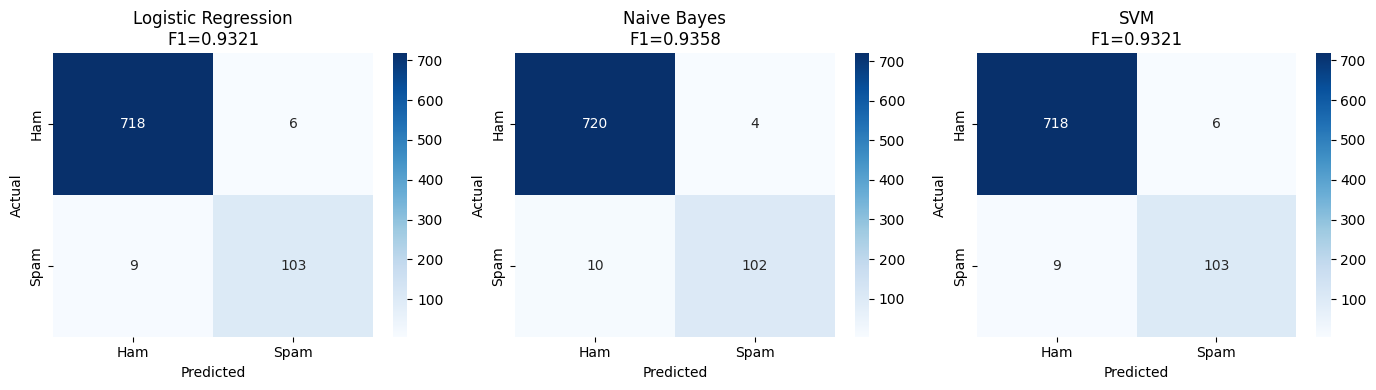

In [30]:
# Confusion matrices for all models on test data
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, name, y_pred in zip(axes, models, predictions):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
    ax.set_title(f'{name}\nF1={f1_score(y_test, y_pred):.4f}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

AUPRC and AUROC on Test Data:
Logistic Regression       AUPRC: 0.9638  AUROC: 0.9836
Naive Bayes               AUPRC: 0.9708  AUROC: 0.9880
SVM                       AUPRC: 0.9673  AUROC: 0.9846


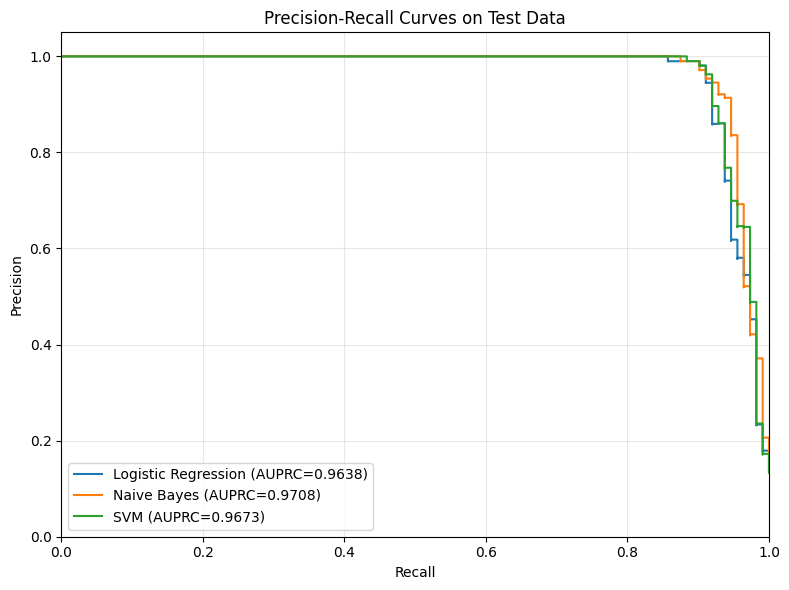

In [33]:
# AUPRC (Area Under Precision-Recall Curve) - better metric for imbalanced data
from sklearn.metrics import average_precision_score, roc_auc_score

# Get probability/decision scores for test data
y_test_prob_lr = lr_tuned.predict_proba(X_test_tfidf)[:, 1]
y_test_prob_nb = nb_tuned.predict_proba(X_test_tfidf)[:, 1]
y_test_score_svm = svm_tuned.decision_function(X_test_tfidf)

# Calculate AUPRC and AUROC
scores = [y_test_prob_lr, y_test_prob_nb, y_test_score_svm]

print("AUPRC and AUROC on Test Data:")
for name, score in zip(models, scores):
    auprc = average_precision_score(y_test, score)
    auroc = roc_auc_score(y_test, score)
    print(f"{name:25} AUPRC: {auprc:.4f}  AUROC: {auroc:.4f}")

# Precision-Recall Curves
fig, ax = plt.subplots(figsize=(8, 6))

for name, score in zip(models, scores):
    precision, recall, _ = precision_recall_curve(y_test, score)
    auprc = average_precision_score(y_test, score)
    ax.step(recall, precision, where='post', label=f'{name} (AUPRC={auprc:.4f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves on Test Data')
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.show()

### Conclusion

**Test Set Results:**

| Model | Accuracy | Precision | Recall | F1 | AUPRC | AUROC | FP | FN |
|-------|----------|-----------|--------|------|-------|-------|----|----|
| Logistic Regression | 98.21% | 94.50% | 91.96% | 0.9321 | 0.9638 | 0.9836 | 6 | 9 |
| Naive Bayes | 98.33% | 96.23% | 91.07% | 0.9358 | 0.9708 | 0.9880 | 4 | 10 |
| SVM | 98.21% | 94.50% | 91.96% | 0.9321 | 0.9673 | 0.9846 | 6 | 9 |

**Best Model Selection:**

Based on F1 score and AUPRC, **Naive Bayes** is the best performing model with F1 = 0.9358 and AUPRC = 0.9708, followed by SVM and Logistic Regression.

---

**Cost-Weighted Consideration:**

In the class example, we discussed that false positives (marking legitimate email as spam) are 10x more costly than false negatives (letting spam through) — losing an important email is worse than seeing some spam.

| Model | FP | FN | Weighted Cost (10×FP + FN) |
|-------|----|----|---------------------------|
| Logistic Regression | 6 | 9 | 69 |
| Naive Bayes | 4 | 10 | 50 |
| SVM | 6 | 9 | 69 |

With this cost consideration, Naive Bayes remains the best choice with:
- Highest AUPRC (0.9708)
- Lowest false positives (4)
- Lowest weighted cost (50)
- Highest precision (96.23%)